**Machine Learning Model**

In [18]:
# ================================
# Import Required Libraries
# ================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

In [5]:
# ================================
# Load Data from prepcoesssing file (already saved)
# ================================

df = pd.read_csv('processed_data.csv')

**Encode Categorical Variables - Machine learning models cannot read text values.**

In [8]:
df_encoded = pd.get_dummies(df, drop_first=True)

# pd.get_dummies() converts categorical variables into numerical dummy variables (0 and 1)

#drop_first=True removes one column to avoid multicollinearity.

In [19]:
# ================================
# Define Features and Target
# ================================

X = df_encoded.drop('Is_Fraud', axis=1)

#It removes the column Is_Fraud from the dataframe and stores the remaining columns in X. axis=1 → tells Pandas to drop a column (not a row)

y = df_encoded['Is_Fraud']


In [10]:
# ================================
# Train Test Split
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#test_size=0.2 - This means 20% of data will be used for testing.
#random_state = 42 - Every time you run the code, you get the same train/test split.

In [11]:
# ================================
# Logistic Regression Model
# ================================

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9733333333333334
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       556
           1       0.89      0.73      0.80        44

    accuracy                           0.97       600
   macro avg       0.93      0.86      0.89       600
weighted avg       0.97      0.97      0.97       600



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
# ================================
# Decision Tree Model
# ================================

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9966666666666667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       556
           1       0.98      0.98      0.98        44

    accuracy                           1.00       600
   macro avg       0.99      0.99      0.99       600
weighted avg       1.00      1.00      1.00       600



In [13]:
# ================================
# Random Forest Model
# ================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9933333333333333
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       556
           1       1.00      0.91      0.95        44

    accuracy                           0.99       600
   macro avg       1.00      0.95      0.97       600
weighted avg       0.99      0.99      0.99       600



In [14]:
# ================================
# Feature Importance
# ================================
# This shows which features detect fraud.

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(10)

,0
Transaction_Hour,0.200851
night_transaction,0.103577
Payment_Method_UPI,0.084544
Transaction_Amount,0.068581
Payment_Method_Net Banking,0.036691
avg_customer_spending,0.035337
Customer_ID,0.034632
Device_Type_Mobile,0.008055
abnormal_transaction,0.006652
Location_Mumbai,0.005430


In [15]:
# ================================
# Model Comparison
# ================================

models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy
})

comparison


,Model,Accuracy
0,Logistic Regression,0.973333
1,Decision Tree,0.996667
2,Random Forest,0.993333


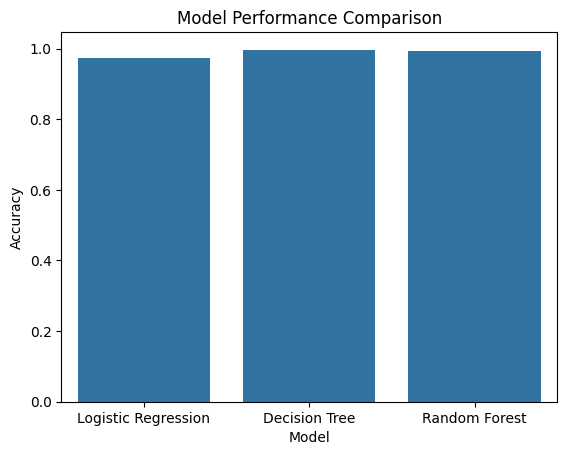

In [17]:
sns.barplot(x='Model', y='Accuracy', data=comparison)
plt.title("Model Performance Comparison")
plt.show()